# CST3990 Coursework 2 Implementation Notebook

## Project title
A comparative analysis of similarity measurement techniques for an academic recommendation system

## Purpose of this notebook

This notebook implements the first stage of a controlled experimental pipeline for scholarly recommendation.

The purpose of this stage is to:

1. extract a suitable dataset of academic publications from OpenAlex,
2. reconstruct and clean document abstracts,
3. analyse the characteristics of the extracted dataset,
4. implement a lexical baseline using **Term Frequency–Inverse Document Frequency (TF–IDF)**, and
5. implement a semantic representation using **transformer-based sentence embeddings**.

## Why this pipeline design is appropriate

This project uses a controlled pipeline rather than a full deployed recommendation system because the main aim is comparative evaluation. A controlled design makes it possible to compare lexical and semantic similarity approaches under the same dataset conditions, which improves fairness and methodological clarity.

Recent literature on scientific paper recommendation highlights the importance of reproducible comparisons, careful dataset construction, and clear evaluation design when comparing recommendation methods (Kreutz and Schenkel, 2022; Zhang et al., 2023).

## Key sources informing this stage

- Manning, Raghavan and Schütze (2008)
- Kreutz and Schenkel (2022)
- Cohan et al. (2020)
- Singh et al. (2023)
- OpenAlex documentation

In [4]:
# Install the core libraries required for this stage of the experiment.
#
# pandas: data handling
# requests: OpenAlex API calls
# scikit-learn: lexical vectorisation and similarity computation
# sentence-transformers: semantic document embeddings
# matplotlib: exploratory plots
# tqdm: progress indicators for slower operations

!pip -q install pandas requests scikit-learn sentence-transformers matplotlib tqdm

In [5]:
# Import all required libraries and define basic reproducibility settings.

import os
import json
import time
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_rel

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Create a local folder for outputs generated during the notebook run.
# This makes it easier to upload plots and result files to GitHub later.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Environment ready")
print("Random seed:", SEED)

Environment ready
Random seed: 42


## 1. Data source and extraction strategy

The dataset used in this project is extracted from **OpenAlex**, an open scholarly metadata database. OpenAlex provides structured information about academic works, including titles, publication years, citation counts, concepts, and abstracts.

A particularly important detail is that OpenAlex stores abstracts as an **inverted index** rather than plain text. This means the abstract must be reconstructed before textual similarity methods can be applied.

### Why OpenAlex is appropriate for this project

OpenAlex is suitable for this project because:

- it is publicly accessible,
- it contains scholarly metadata relevant to recommendation tasks,
- it can be queried reproducibly through an application programming interface,
- it does not involve human participant data or sensitive personal data.

### Filtering strategy

To keep the experiment controlled and interpretable, the extraction is restricted to:

- English-language publications,
- publications with available abstracts,
- publications published from 2015 onward,
- publications associated with Computer Science,
- publications with fewer than 1000 citations.

These restrictions are justified because they reduce topical noise, limit extreme citation outliers, and produce a dataset that is more suitable for early-stage controlled evaluation.

In [6]:
# OpenAlex stores abstracts in an inverted index format.
# In this structure, each token is mapped to one or more positions in the abstract.
#
# For example, a simplified abstract such as:
# "deep learning improves ranking"
# might be stored as:
# {
#   "deep": [0],
#   "learning": [1],
#   "improves": [2],
#   "ranking": [3]
# }
#
# The function below reconstructs the original abstract text in reading order.

def inverted_index_to_text(inv_idx):

    # Return None if the input is not a valid dictionary.
    if not isinstance(inv_idx, dict):
        return None

    position_map = defaultdict(list)

    # Build a mapping from position -> token(s)
    for token, positions in inv_idx.items():
        for pos in positions:
            position_map[pos].append(token)

    words = []

    # Rebuild the sequence in order of positions
    for i in range(max(position_map.keys()) + 1):
        words.append(position_map[i][0] if i in position_map else "")

    return " ".join(words).strip()

In [7]:
# Define the OpenAlex API settings used for extraction.
#
# The Computer Science concept identifier is used to keep the corpus within a single
# broad field, which improves interpretability at this stage of the experiment.
#
# The citation limit is included because earlier unrestricted samples produced
# unrealistic averages dominated by very highly cited landmark papers.

BASE_URL = "https://api.openalex.org/works"

# OpenAlex concept identifier used to filter for Computer Science
CS_CONCEPT_ID = "C41008148"

FILTER = (
    "has_abstract:true,"
    "language:en,"
    "from_publication_date:2015-01-01,"
    f"concepts.id:{CS_CONCEPT_ID},"
    "cited_by_count:<1000"
)

PER_PAGE = 200
PAGES = 5

print("Extraction filter:")
print(FILTER)

Extraction filter:
has_abstract:true,language:en,from_publication_date:2015-01-01,concepts.id:C41008148,cited_by_count:<1000


In [8]:
# Extract a controlled sample from OpenAlex using cursor-based pagination.
#
# Each extracted record stores the information needed for the next stages:
# - identifier
# - title
# - year
# - citation count
# - concepts
# - abstract inverted index

all_rows = []
cursor = "*"

for page in range(PAGES):

    params = {
        "filter": FILTER,
        "per-page": PER_PAGE,
        "cursor": cursor
    }

    response = requests.get(BASE_URL, params=params, timeout=60)
    response.raise_for_status()
    payload = response.json()

    results = payload.get("results", [])
    cursor = payload.get("meta", {}).get("next_cursor")

    for work in results:
        all_rows.append({
            "id": work.get("id"),
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "citations": work.get("cited_by_count"),
            "concepts": work.get("concepts"),
            "abstract_index": work.get("abstract_inverted_index")
        })

    print(f"Completed page {page + 1}/{PAGES}. Total records so far: {len(all_rows)}")
    time.sleep(0.2)

df_raw = pd.DataFrame(all_rows)

# Save minimal extraction metadata so the run is documented.
run_metadata = {
    "base_url": BASE_URL,
    "filter": FILTER,
    "per_page": PER_PAGE,
    "pages": PAGES,
    "records_extracted": int(len(df_raw)),
    "seed": SEED
}

with open(os.path.join(OUTPUT_DIR, "run_metadata.json"), "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Total records extracted:", len(df_raw))
df_raw.head(3)

Completed page 1/5. Total records so far: 200
Completed page 2/5. Total records so far: 400
Completed page 3/5. Total records so far: 600
Completed page 4/5. Total records so far: 800
Completed page 5/5. Total records so far: 1000
Total records extracted: 1000


,id,title,year,citations,concepts,abstract_index
0,https://openalex.org/W2317136217,IMAGE ARTIFACTS IN OPTICAL COHERENCE TOMOGRAPH...,2015,999,"[{'id': 'https://openalex.org/C31972630', 'wik...","{'Image': [0], 'artifacts': [1], 'are': [2], '..."
1,https://openalex.org/W2518696367,Surface energies of elemental crystals,2016,999,"[{'id': 'https://openalex.org/C2776799497', 'w...","{'The': [0, 116], 'surface': [1, 24, 35, 46, 7..."
2,https://openalex.org/W2606037183,A Bioinspired Mineral Hydrogel as a Self‐Heala...,2017,999,"[{'id': 'https://openalex.org/C192562407', 'wi...","{'In': [0, 45], 'the': [1, 71, 120], 'past': [..."


## 2. Data cleaning and abstract reconstruction

The raw records must now be transformed into a usable working dataset.

This stage includes:

- reconstructing abstract text from the OpenAlex inverted index,
- removing records with missing abstracts,
- removing records with very short or low-information abstracts,
- preserving concept metadata for later evaluation.

This stage matters because the quality of the document representations depends heavily on the quality of the underlying text.

In [9]:
# Create a working copy of the extracted data.
# Keeping a separate working dataframe is useful because it preserves the raw extraction
# if later debugging or reprocessing becomes necessary.

df = df_raw.copy()

# Reconstruct the abstract text from the OpenAlex inverted index.
df["abstract"] = df["abstract_index"].apply(inverted_index_to_text)

# Remove the raw inverted index column once the plain-text abstract is available.
df = df.drop(columns=["abstract_index"])

# Remove rows with missing or very short abstracts.
# A threshold is applied to reduce weak records that are unlikely to support
# meaningful lexical or semantic representations.
df = df[df["abstract"].notna() & (df["abstract"].str.len() > 80)]

df.reset_index(drop=True, inplace=True)

print("Documents after cleaning:", len(df))
df[["title", "year", "citations", "abstract"]].head(3)

df.to_csv(os.path.join(OUTPUT_DIR, "cleaned_openalex_cs_dataset.csv"), index=False)
print("Cleaned dataset saved")

Documents after cleaning: 978
Cleaned dataset saved


In [10]:
df.head()

,id,title,year,citations,concepts,abstract
0,https://openalex.org/W2317136217,IMAGE ARTIFACTS IN OPTICAL COHERENCE TOMOGRAPH...,2015,999,"[{'id': 'https://openalex.org/C31972630', 'wik...",Image artifacts are common and can lead to inc...
1,https://openalex.org/W2518696367,Surface energies of elemental crystals,2016,999,"[{'id': 'https://openalex.org/C2776799497', 'w...",The surface energy is a fundamental property o...
2,https://openalex.org/W2606037183,A Bioinspired Mineral Hydrogel as a Self‐Heala...,2017,999,"[{'id': 'https://openalex.org/C192562407', 'wi...","In the past two decades, artificial skin-like ..."
3,https://openalex.org/W2918612296,Tailoring the photoluminescence of atomically ...,2019,999,"[{'id': 'https://openalex.org/C2778402822', 'w...",Due to their atomically precise structures and...
4,https://openalex.org/W3103891289,"Chatbots: History, technology, and applications",2020,999,"[{'id': 'https://openalex.org/C41008148', 'wik...","This literature review presents the History, T..."


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Preliminary dataset analysis

Before implementing recommendation methods, it is useful to inspect the dataset itself.

This step helps answer several practical questions:

- Is the extracted sample large enough for initial testing?
- Are abstracts long enough to support document representation?
- Has the citation filter reduced outlier skew?
- Does the dataset look stable enough for lexical and semantic modelling?

This kind of exploratory analysis is important because it provides evidence that the experimental data has been examined rather than used blindly.

In [12]:
# Compute descriptive statistics for the cleaned dataset.

df["abstract_length_words"] = df["abstract"].apply(lambda x: len(x.split()))

print("Total documents:", len(df))
print("Average abstract length:", df["abstract_length_words"].mean())
print("Median abstract length:", df["abstract_length_words"].median())
print("Average citation count:", df["citations"].mean())
print("Median citation count:", df["citations"].median())

# Save the statistics so they can be backed up to GitHub.
dataset_stats = {
    "documents": int(len(df)),
    "average_abstract_length_words": float(df["abstract_length_words"].mean()),
    "median_abstract_length_words": float(df["abstract_length_words"].median()),
    "average_citation_count": float(df["citations"].mean()),
    "median_citation_count": float(df["citations"].median())
}

with open(os.path.join(OUTPUT_DIR, "dataset_stats.json"), "w") as f:
    json.dump(dataset_stats, f, indent=2)

Total documents: 978
Average abstract length: 167.09100204498978
Median abstract length: 162.0
Average citation count: 943.3108384458078
Median citation count: 939.0


### Why the following plots are useful

The abstract length distribution helps show whether the extracted documents contain enough textual information for similarity modelling.

The citation distribution helps confirm that the filtering strategy has reduced the impact of very highly cited outliers.

Together, these plots provide a basic but important validation of the dataset design.

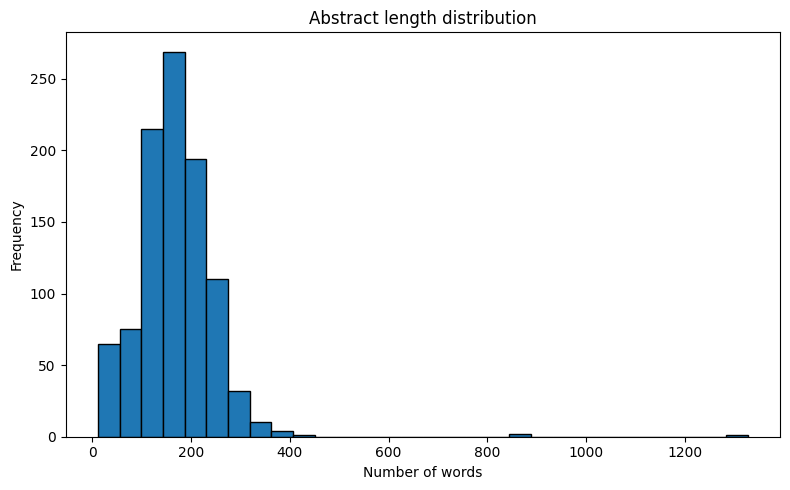

In [13]:
# Plot abstract length distribution.

plt.figure(figsize=(8, 5))
plt.hist(df["abstract_length_words"], bins=30, edgecolor="black")
plt.title("Abstract length distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "abstract_length_distribution.png"), dpi=200)
plt.show()

## 4. Lexical similarity baseline: Term Frequency–Inverse Document Frequency

The first document representation used in this project is **Term Frequency–Inverse Document Frequency (TF–IDF)**.

Term Frequency–Inverse Document Frequency is a standard lexical weighting method in information retrieval. It increases the weight of terms that appear frequently in a specific document but less frequently across the corpus as a whole (Manning, Raghavan and Schütze, 2008).

This approach is used as the lexical baseline because:

- it is well established in information retrieval,
- it is computationally efficient,
- it is interpretable,
- it provides a clear reference point before more complex semantic methods are introduced.

Once the abstracts are converted into TF–IDF vectors, similarity between documents can later be computed using cosine similarity.

In [14]:
# Build lexical document vectors using Term Frequency–Inverse Document Frequency.
#
# stop_words="english" reduces the influence of extremely common function words
# that are unlikely to improve discrimination between academic abstracts.
#
# max_features is capped to keep the representation computationally manageable
# during development while still retaining substantial lexical information.

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=8000
)

X_tfidf = tfidf_vectorizer.fit_transform(df["abstract"])

print("Term Frequency–Inverse Document Frequency matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

Term Frequency–Inverse Document Frequency matrix shape: (978, 8000)
Vocabulary size: 8000


## 5. Semantic similarity representation: transformer-based sentence embeddings

Lexical similarity methods depend strongly on word overlap. As a result, they may fail when two papers describe similar ideas using different terminology.

To address this limitation, the second representation uses **transformer-based sentence embeddings**. These are dense vectors designed to capture contextual and semantic meaning.

This type of representation is relevant to scholarly recommendation because scientific papers often express related ideas using varied vocabulary. Recent research has shown the importance of strong scientific document embeddings for retrieval, ranking, and related downstream tasks (Cohan et al., 2020; Singh et al., 2023).

In this implementation, a practical Sentence-Transformers model is used to produce semantic representations. This choice balances methodological strength with computational feasibility in Google Colab.

In [15]:
from sentence_transformers import SentenceTransformer

# Load a pretrained transformer-based sentence embedding model.
# This model is lightweight enough for Colab while still providing
# a meaningful semantic baseline for comparison.

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate semantic embeddings for all abstracts.
# normalize_embeddings=True ensures that dot product is equivalent to cosine similarity,
# which keeps the comparison with the lexical branch methodologically consistent.

embeddings = embedding_model.encode(
    df["abstract"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True

)

# Save embeddings so the computation does not need to be repeated unnecessarily.
np.save(os.path.join(OUTPUT_DIR, "semantic_embeddings.npy"), embeddings)

print("Semantic embedding matrix shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Semantic embedding matrix shape: (978, 384)


## End of Implementation stage

At this point, the notebook has completed the first major implementation milestone:

- extraction of scholarly metadata from OpenAlex,
- abstract reconstruction,
- dataset cleaning,
- preliminary dataset analysis,
- lexical representation using Term Frequency–Inverse Document Frequency,
- semantic representation using transformer-based sentence embeddings.

This is a substantial stage of progress because it establishes the full document representation layer of the recommendation pipeline.

The next stage will build on this by:
- generating ranked recommendations,
- defining relevance using concept overlap,
- evaluating recommendation quality using ranking metrics,
- comparing lexical and semantic performance.

## Key sources supporting Implementation

- Manning, C.D., Raghavan, P. and Schütze, H. (2008) *Introduction to Information Retrieval*. Cambridge: Cambridge University Press.
- Cohan, A., Feldman, S., Beltagy, I., Downey, D. and Weld, D.S. (2020) ‘SPECTER: Document-level representation learning using citation-informed transformers’, *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics*, pp. 2270–2282.
- Kreutz, C.K. and Schenkel, R. (2022) ‘Scientific paper recommendation systems: a literature review of recent publications’, *International Journal on Digital Libraries*, 23(4), pp. 335–369.
- Singh, A., D’Arcy, M., Cohan, A., Downey, D. and Feldman, S. (2023) ‘SciRepEval: A multi-format benchmark for scientific document representations’, *Proceedings of EMNLP 2023*, pp. 5548–5566.
- Zhang, Z. et al. (2023) ‘Scholarly recommendation systems: a literature survey’, *Knowledge and Information Systems*, 65, pp. 4433–4478.
- OpenAlex documentation.

# Section 2: Implementing ranking relevance definition and evaluation metrics

## 6. Generating recommendation rankings

Once lexical and semantic representations have been created, the next step is to generate ranked recommendations for a given seed paper.

For each seed document, similarity scores are computed against all other documents in the dataset. These scores are then used to rank candidate papers from most similar to least similar.

This stage is important because recommendation quality depends not only on document representation, but also on how candidate documents are ordered and returned to the user.

In [36]:
# Define helper functions for recommendation ranking.
# These functions return the top-ranked recommended papers for a selected seed document.

def get_top_recommendations_tfidf(seed_index, top_n=5):
    similarity_scores = cosine_similarity(X_tfidf[seed_index], X_tfidf).flatten()

    # Prevent the seed document from recommending itself
    similarity_scores[seed_index] = -1

    ranked_indices = np.argsort(similarity_scores)[::-1][:top_n]

    output = df.loc[ranked_indices, ["title", "year", "citations"]].copy()
    output["doc_index"] = ranked_indices
    output["similarity_score"] = similarity_scores[ranked_indices]

    return output.reset_index(drop=True)

def get_top_recommendations_embeddings(seed_index, top_n=5):
    similarity_scores = embeddings @ embeddings[seed_index]
    similarity_scores[seed_index] = -1

    ranked_indices = np.argsort(similarity_scores)[::-1][:top_n]

    output = df.loc[ranked_indices, ["title", "year", "citations"]].copy()
    output["doc_index"] = ranked_indices
    output["similarity_score"] = similarity_scores[ranked_indices]

    return output.reset_index(drop=True)

## 7. Initial recommendation examples

Before formal evaluation, it is useful to inspect a small number of recommendation outputs manually.

This helps confirm that:
- the ranking functions are working,
- the returned recommendations appear meaningful,
- lexical and semantic approaches produce different behaviour that can later be analysed more formally.

In [17]:
# Display recommendation examples for a few seed papers.

seed_examples = [0, 3, 7]

for seed_idx in seed_examples:
    print("=" * 100)
    print("Seed paper:")
    print(df.loc[seed_idx, "title"])
    print("-" * 100)

    print("Lexical similarity recommendations:")
    display(get_top_recommendations_tfidf(seed_idx, top_n=5))

    print("Semantic similarity recommendations:")
    display(get_top_recommendations_embeddings(seed_idx, top_n=5))

    print("\n")

Seed paper:
IMAGE ARTIFACTS IN OPTICAL COHERENCE TOMOGRAPHY ANGIOGRAPHY
----------------------------------------------------------------------------------------------------
Lexical similarity recommendations:


,title,year,citations,doc_index,similarity_score
0,Compression Artifacts Reduction by a Deep Conv...,2015,909,827,0.200490
1,Infrared and Visible Image Fusion via Decoupli...,2022,961,303,0.156058
2,Clearing the Skies: A Deep Network Architectur...,2017,948,407,0.135399
3,EEG artifact removal—state-of-the-art and guid...,2015,921,694,0.129430
4,Deep Supervised Hashing for Fast Image Retrieval,2016,923,670,0.117120


Semantic similarity recommendations:


,title,year,citations,doc_index,similarity_score
0,X-ray computed tomography,2021,937,510,0.390391
1,The effectiveness of virtual and augmented rea...,2017,979,162,0.378229
2,Standardized image interpretation and post-pro...,2020,921,705,0.332326
3,Measuring the optimal exposure for single part...,2015,925,644,0.318808
4,A review of medical image data augmentation te...,2021,915,768,0.307639




Seed paper:
Tailoring the photoluminescence of atomically precise nanoclusters
----------------------------------------------------------------------------------------------------
Lexical similarity recommendations:


...

,title,year,citations,doc_index,similarity_score
0,Nanomedicine Applications of Hybrid Nanomateri...,2015,966,260,0.530130
1,Crucial breakthrough of second near-infrared b...,2018,986,104,0.478397
2,Smart nanocarrier-based drug delivery systems ...,2018,963,288,0.462288
3,The photophysics of photoredox catalysis: a ro...,2016,933,543,0.452876
4,Recent Advances in Photoelectrochemical Sensin...,2019,920,718,0.442013




Seed paper:
Path Planning and Tracking for Vehicle Collision Avoidance Based on Model Predictive Control With Multiconstraints
----------------------------------------------------------------------------------------------------
Lexical similarity recommendations:


,title,year,citations,doc_index,similarity_score
0,Convolutional Features for Correlation Filter ...,2015,997,20,0.160274
1,Planning and Decision-Making for Autonomous Ve...,2018,908,842,0.153633
2,Direct and Indirect Effects,2022,924,653,0.123117
3,HOTA: A Higher Order Metric for Evaluating Mul...,2020,960,314,0.118170
4,Detection and Tracking Meet Drones Challenge,2021,968,251,0.116262


Semantic similarity recommendations:


,title,year,citations,doc_index,similarity_score
0,Planning and Decision-Making for Autonomous Ve...,2018,908,842,0.513683
1,UAV-Enabled Intelligent Transportation Systems...,2017,928,604,0.354237
2,Review on model predictive control: an enginee...,2021,964,282,0.327357
3,"FAST-LIO: A Fast, Robust LiDAR-Inertial Odomet...",2021,929,601,0.319415
4,"Artificial intelligence, machine learning and ...",2023,994,52,0.290422


In [18]:
# Generate top-N recommendations using TF-IDF (lexical similarity)
def get_top_recommendations_tfidf(seed_index, top_n=5):

    # Compute cosine similarity between the seed paper and all others
    similarity_scores = cosine_similarity(X_tfidf[seed_index], X_tfidf).flatten()

    # Exclude the seed paper itself
    similarity_scores[seed_index] = -1

    # Rank documents by similarity
    ranked_indices = np.argsort(similarity_scores)[::-1][:top_n]

    # Return relevant metadata with similarity scores
    output = df.loc[ranked_indices, ["title", "year", "citations"]].copy()
    output["doc_index"] = ranked_indices
    output["similarity_score"] = similarity_scores[ranked_indices]

    return output.reset_index(drop=True)


# Generate top-N recommendations using embeddings (semantic similarity)
def get_top_recommendations_embeddings(seed_index, top_n=5):

    # Dot product acts as cosine similarity since embeddings are normalised
    similarity_scores = embeddings @ embeddings[seed_index]

    similarity_scores[seed_index] = -1
    ranked_indices = np.argsort(similarity_scores)[::-1][:top_n]

    output = df.loc[ranked_indices, ["title", "year", "citations"]].copy()
    output["doc_index"] = ranked_indices
    output["similarity_score"] = similarity_scores[ranked_indices]

    return output.reset_index(drop=True)

## 8. Relevance definition using OpenAlex concepts

To evaluate recommendation quality, a relevance definition is needed.

Because this project does not use human-labelled relevance judgements, relevance is approximated using shared OpenAlex research concepts.

A recommended paper is treated as relevant if it shares at least a specified number of concepts with the seed paper.

Two thresholds are tested:
- threshold = 1, meaning at least one shared concept
- threshold = 2, meaning at least two shared concepts

This sensitivity analysis is included to avoid relying on a single arbitrary relevance assumption.

In [19]:
# Define concept-based relevance functions.

def concept_id_set(row):
    concepts = row["concepts"]
    if not isinstance(concepts, list):
        return set()

    return {
        c["id"]
        for c in concepts
        if isinstance(c, dict) and c.get("id")
    }


def is_relevant(seed_row, candidate_row, threshold=1):
    seed_set = concept_id_set(seed_row)
    candidate_set = concept_id_set(candidate_row)
    return len(seed_set.intersection(candidate_set)) >= threshold

In [20]:
# Extract concept IDs from a document
def concept_id_set(row):

    concepts = row["concepts"]

    if not isinstance(concepts, list):
        return set()

    return {
        c["id"]
        for c in concepts
        if isinstance(c, dict) and c.get("id")
    }


# Determine relevance based on shared concepts
def is_relevant(seed_row, candidate_row, threshold=1):

    seed_set = concept_id_set(seed_row)
    candidate_set = concept_id_set(candidate_row)

    return len(seed_set.intersection(candidate_set)) >= threshold

## 9. Evaluation metrics

The following evaluation metrics are used in this notebook:

1. **Precision at k**  
   Measures the proportion of the top-k recommendations that are relevant.

2. **Recall at k**  
   Measures how many of the relevant items are captured within the top-k recommendations.

3. **F1-score**  
   Combines precision and recall into a single balanced metric.

4. **Normalised Discounted Cumulative Gain at k**  
   Measures ranking quality while giving greater weight to relevant papers appearing earlier in the ranked list.

These metrics are appropriate for scholarly recommendation because users typically focus on the first few returned papers rather than the full ranked list.

In [34]:
# Define evaluation metric functions.

import math

def precision_at_k(relevance_list, k):
    rels = relevance_list[:k]
    return sum(rels) / k


def recall_at_k(relevance_list, total_relevant, k):
    if total_relevant == 0:
        return 0.0
    rels = relevance_list[:k]
    return sum(rels) / total_relevant


def f1_score_value(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def discounted_cumulative_gain_at_k(relevance_list, k):
    rels = relevance_list[:k]
    score = 0.0

    for i, rel in enumerate(rels, start=1):
        score += (2 ** rel - 1) / math.log2(i + 1)

    return score


def normalised_discounted_cumulative_gain_at_k(relevance_list, k):
    dcg = discounted_cumulative_gain_at_k(relevance_list, k)
    ideal = sorted(relevance_list, reverse=True)
    idcg = discounted_cumulative_gain_at_k(ideal, k)

    if idcg == 0:
        return 0.0

    return dcg / idcg

## 10. Experimental evaluation procedure

The experiment compares lexical and semantic recommendation quality across multiple seed papers.

For each seed paper:

1. lexical similarity scores are computed and ranked,
2. semantic similarity scores are computed and ranked,
3. relevance is assigned using concept overlap,
4. evaluation metrics are computed at different values of k.

Using multiple seed papers improves stability and reduces the chance of overinterpreting a single example.

In [22]:
# Evaluate both recommendation approaches across multiple seed papers.

def evaluate_model(mode, k_values=(5, 10, 20), thresholds=(1, 2), n_seeds=25):
    rows = []

    available_indices = list(range(len(df)))
    rng = random.Random(SEED)
    rng.shuffle(available_indices)
    seed_indices = available_indices[:min(n_seeds, len(df))]

    for threshold in thresholds:
        for seed_idx in tqdm(seed_indices, desc=f"Evaluating {mode}, threshold {threshold}"):
            seed_row = df.loc[seed_idx]

            if mode == "lexical":
                similarity_scores = cosine_similarity(X_tfidf[seed_idx], X_tfidf).flatten()
            elif mode == "semantic":
                similarity_scores = embeddings @ embeddings[seed_idx]
            else:
                raise ValueError("Mode must be lexical or semantic")

            similarity_scores[seed_idx] = -1
            ranked_indices = np.argsort(similarity_scores)[::-1]

            relevance_list = [
                1 if is_relevant(seed_row, df.loc[idx], threshold=threshold) else 0
                for idx in ranked_indices
            ]

            total_relevant = sum(relevance_list)

            for k in k_values:
                precision = precision_at_k(relevance_list, k)
                recall = recall_at_k(relevance_list, total_relevant, k)
                f1 = f1_score_value(precision, recall)
                ndcg = normalised_discounted_cumulative_gain_at_k(relevance_list, k)

                rows.append({
                    "mode": mode,
                    "seed_index": seed_idx,
                    "threshold": threshold,
                    "k": k,
                    "precision_at_k": precision,
                    "recall_at_k": recall,
                    "f1_score": f1,
                    "ndcg_at_k": ndcg
                })

    return pd.DataFrame(rows)

results_lexical = evaluate_model("lexical")
results_semantic = evaluate_model("semantic")

results = pd.concat([results_lexical, results_semantic], ignore_index=True)

results.to_csv(os.path.join(OUTPUT_DIR, "evaluation_results_detailed.csv"), index=False)

print("Detailed evaluation results saved")
results.head()

Evaluating semantic, threshold 2: 100%|██████████| 25/25 [00:01<00:00, 14.88it/s]

Detailed evaluation results saved


,mode,seed_index,threshold,k,precision_at_k,recall_at_k,f1_score,ndcg_at_k
0,lexical,56,1,5,1.0,0.005112,0.010173,1.0
1,lexical,56,1,10,1.0,0.010225,0.020243,1.0
2,lexical,56,1,20,1.0,0.020450,0.040080,1.0
3,lexical,903,1,5,1.0,0.005112,0.010173,1.0
4,lexical,903,1,10,1.0,0.010225,0.020243,1.0


## 11. Results summary

To compare the two approaches clearly, metric scores are aggregated across seed papers.

Both mean values and standard deviations are reported. Mean values indicate overall performance, while standard deviations provide an indication of stability across different seeds.

In [55]:
summary = (
    results.groupby(["mode", "threshold", "k"])
    .agg(
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_std=("precision_at_k", "std"),
        recall_at_k_mean=("recall_at_k", "mean"),
        recall_at_k_std=("recall_at_k", "std"),
        f1_mean=("f1_score", "mean"),
        f1_std=("f1_score", "std"),
        ndcg_at_k_mean=("ndcg_at_k", "mean"),
        ndcg_at_k_std=("ndcg_at_k", "std")
    )
    .reset_index()
)

summary.to_csv(os.path.join(OUTPUT_DIR, "evaluation_summary.csv"), index=False)
summary = summary.round(4)
summary = summary.sort_values(by=["threshold", "k", "mode"])

summary

,mode,threshold,k,precision_at_k_mean,precision_at_k_std,recall_at_k_mean,recall_at_k_std,f1_mean,f1_std,ndcg_at_k_mean,ndcg_at_k_std
0,lexical,1,5,1.000,0.0000,0.0051,0.0000,0.0102,0.0000,1.0000,0.0000
6,semantic,1,5,1.000,0.0000,0.0051,0.0000,0.0102,0.0000,1.0000,0.0000
1,lexical,1,10,1.000,0.0000,0.0102,0.0000,0.0202,0.0000,1.0000,0.0000
7,semantic,1,10,1.000,0.0000,0.0102,0.0000,0.0202,0.0000,1.0000,0.0000
2,lexical,1,20,1.000,0.0000,0.0204,0.0000,0.0401,0.0000,1.0000,0.0000
8,semantic,1,20,1.000,0.0000,0.0204,0.0000,0.0401,0.0000,1.0000,0.0000
3,lexical,2,5,0.856,0.2678,0.0076,0.0025,0.0150,0.0049,0.8561,0.2772
9,semantic,2,5,0.920,0.2160,0.0085,0.0030,0.0168,0.0060,0.9088,0.2292
4,lexical,2,10,0.856,0.2382,0.0155,0.0052,0.0303,0.0101,0.8562,0.2490
10,semantic,2,10,0.884,0.2211,0.0162,0.0056,0.0318,0.0109,0.8881,0.2237


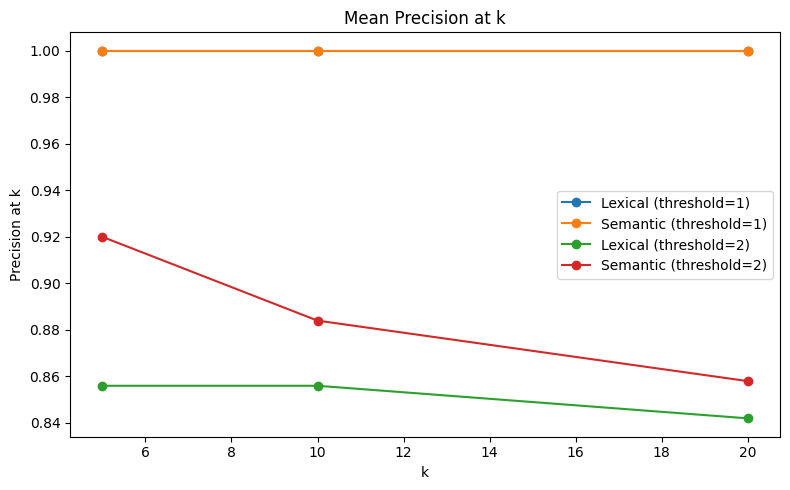

In [57]:
# Plot mean Precision at k.

plt.figure(figsize=(8, 5))

for threshold in sorted(summary["threshold"].unique()):
    for mode in ["lexical", "semantic"]:
        subset = summary[(summary["threshold"] == threshold) & (summary["mode"] == mode)]
        plt.plot(
            subset["k"],
            subset["precision_at_k_mean"],
            marker="o",
            label=f"{mode.title()} (threshold={threshold})"
        )

plt.title("Mean Precision at k")
plt.xlabel("k")
plt.ylabel("Precision at k")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_at_k_comparison.png"), dpi=200)
plt.show()

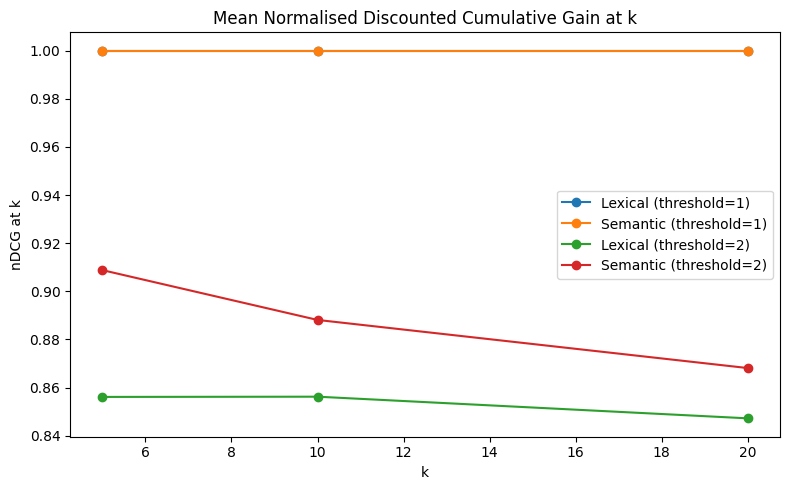

In [58]:
# Plot mean nDCG at k.

plt.figure(figsize=(8, 5))

for threshold in sorted(summary["threshold"].unique()):
    for mode in ["lexical", "semantic"]:
        subset = summary[(summary["threshold"] == threshold) & (summary["mode"] == mode)]
        plt.plot(
            subset["k"],
            subset["ndcg_at_k_mean"],
            marker="o",
            label=f"{mode.title()} (threshold={threshold})"
        )

plt.title("Mean Normalised Discounted Cumulative Gain at k")
plt.xlabel("k")
plt.ylabel("nDCG at k")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ndcg_at_k_comparison.png"), dpi=200)
plt.show()

In [26]:
def recall_at_k(recommended, relevant):
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended) & set(relevant)) / len(relevant)

# Define get_relevant_docs function to identify all relevant documents for a seed
# This uses the 'is_relevant' function defined in a previous cell.
def get_relevant_docs(seed_index, threshold=1):
    relevant_doc_indices = []
    seed_row = df.loc[seed_index]
    for idx in df.index:
        if idx == seed_index: # Skip the seed document itself
            continue
        candidate_row = df.loc[idx]
        if is_relevant(seed_row, candidate_row, threshold=threshold):
            relevant_doc_indices.append(idx)
    return relevant_doc_indices

recall_results = []

for k in [5, 10, 20]:
    recalls_lex = []
    recalls_sem = []

    # Using threshold 1 as defined in the main evaluation for consistency here
    threshold_for_recall_calc = 1

    for i in range(len(df)): # Iterate through all documents as potential seed papers
        rel = get_relevant_docs(i, threshold=threshold_for_recall_calc)

        # If no relevant documents exist for this seed, skip to avoid division by zero
        # and to ensure meaningful recall calculation.
        if not rel:
            continue

        # Get top recommendations and extract their original dataframe indices
        lex = get_top_recommendations_tfidf(i, top_n=k)["doc_index"].tolist()
        sem = get_top_recommendations_embeddings(i, top_n=k)["doc_index"].tolist()

        recalls_lex.append(recall_at_k(lex, rel))
        recalls_sem.append(recall_at_k(sem, rel))

    # Ensure lists are not empty before calculating mean
    mean_lex_recall = np.mean(recalls_lex) if recalls_lex else 0.0
    mean_sem_recall = np.mean(recalls_sem) if recalls_sem else 0.0

    recall_results.append({
        "k": k,
        "Lexical Recall": mean_lex_recall,
        "Semantic Recall": mean_sem_recall
    })

recall_df = pd.DataFrame(recall_results)
print(recall_df)

    k  Lexical Recall  Semantic Recall
0   5        0.005118         0.005118
1  10        0.010235         0.010235
2  20        0.020471         0.020471


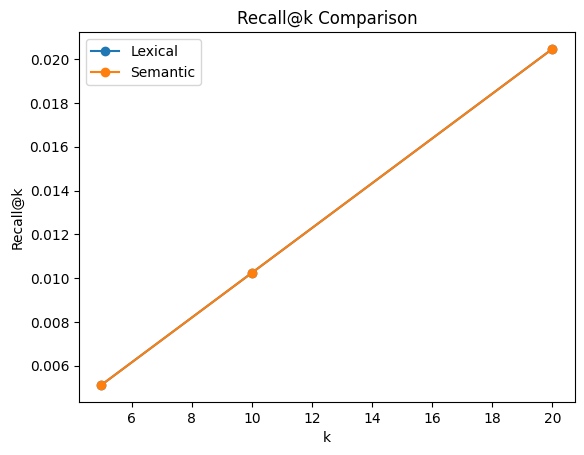

<Figure size 640x480 with 0 Axes>

In [27]:
plt.plot(recall_df["k"], recall_df["Lexical Recall"], marker='o', label="Lexical")
plt.plot(recall_df["k"], recall_df["Semantic Recall"], marker='o', label="Semantic")

plt.title("Recall@k Comparison")
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.legend()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "recall_at_k.png"), dpi=200)

## 12. Statistical comparison

A paired comparison is used to test whether differences between lexical and semantic recommendation scores are likely to reflect consistent performance differences across seed papers.

This does not prove universal superiority of one method, but it strengthens the rigour of the experimental comparison.

In [28]:
from scipy.stats import ttest_rel

def paired_significance_test(metric_name="ndcg_at_k", threshold=1, k=10):
    left = results[
        (results["mode"] == "lexical") &
        (results["threshold"] == threshold) &
        (results["k"] == k)
    ]

    right = results[
        (results["mode"] == "semantic") &
        (results["threshold"] == threshold) &
        (results["k"] == k)
    ]

    merged = pd.merge(
        left[["seed_index", metric_name]],
        right[["seed_index", metric_name]],
        on="seed_index",
        suffixes=("_lexical", "_semantic")
    )

    statistic, p_value = ttest_rel(
        merged[f"{metric_name}_lexical"],
        merged[f"{metric_name}_semantic"]
    )

    return merged, statistic, p_value

paired_data, t_stat, p_val = paired_significance_test(metric_name="ndcg_at_k", threshold=1, k=10)

print("Paired t-test on nDCG at k=10, threshold=1")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("Number of matched seeds:", len(paired_data))

Paired t-test on nDCG at k=10, threshold=1
t-statistic: nan
p-value: nan
Number of matched seeds: 25


## 13. Computational efficiency analysis

Because this project is implemented as a controlled pipeline rather than a deployed production system, it is still important to compare not only recommendation quality but also computational feasibility.

This section compares the time required for:
- lexical vector construction,
- semantic embedding generation,
- lexical ranking,
- semantic ranking.

This matters because a more powerful method may also impose a greater computational cost.

In [29]:
# Runtime comparison for lexical and semantic stages.

start_tfidf = time.time()

tfidf_vectorizer_timed = TfidfVectorizer(
    stop_words="english",
    max_features=8000
)
X_tfidf_timed = tfidf_vectorizer_timed.fit_transform(df["abstract"])

end_tfidf = time.time()
tfidf_time = end_tfidf - start_tfidf

start_embed = time.time()

embeddings_timed = embedding_model.encode(
    df["abstract"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

end_embed = time.time()
embedding_time = end_embed - start_embed

seed_index_runtime = 0

start_rank_tfidf = time.time()
tfidf_similarity_scores = cosine_similarity(X_tfidf_timed[seed_index_runtime], X_tfidf_timed).flatten()
tfidf_similarity_scores[seed_index_runtime] = -1
tfidf_ranked = np.argsort(tfidf_similarity_scores)[::-1][:10]
end_rank_tfidf = time.time()
tfidf_ranking_time = end_rank_tfidf - start_rank_tfidf

start_rank_embed = time.time()
embedding_similarity_scores = embeddings_timed @ embeddings_timed[seed_index_runtime]
embedding_similarity_scores[seed_index_runtime] = -1
embedding_ranked = np.argsort(embedding_similarity_scores)[::-1][:10]
end_rank_embed = time.time()
embedding_ranking_time = end_rank_embed - start_rank_embed

runtime_results = pd.DataFrame({
    "Method": [
        "Lexical vector construction",
        "Semantic vector construction",
        "Lexical recommendation generation",
        "Semantic recommendation generation"
    ],
    "Time in seconds": [
        tfidf_time,
        embedding_time,
        tfidf_ranking_time,
        embedding_ranking_time
    ]
})

runtime_results.to_csv(os.path.join(OUTPUT_DIR, "runtime_results.csv"), index=False)
runtime_results

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

,Method,Time in seconds
0,Lexical vector construction,0.182168
1,Semantic vector construction,116.219206
2,Lexical recommendation generation,0.005623
3,Semantic recommendation generation,0.000510


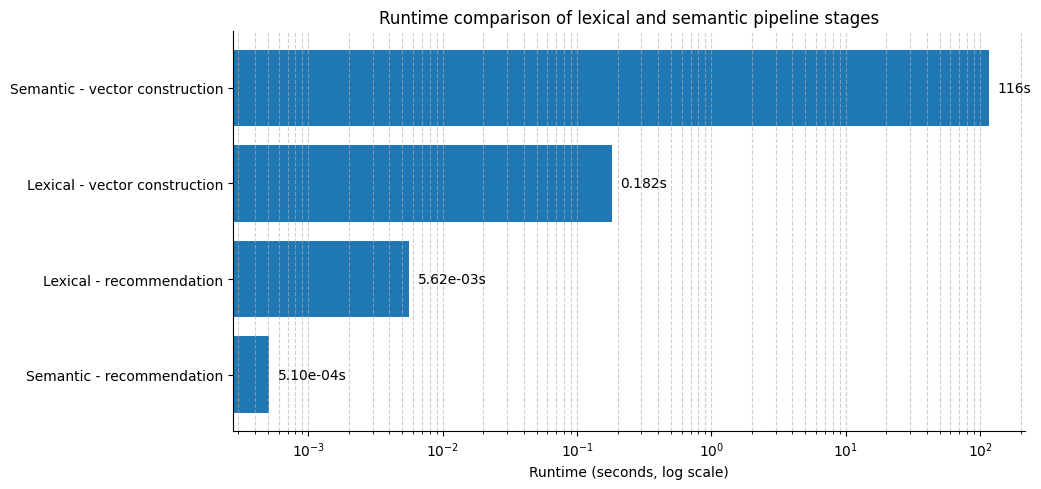

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _format_seconds(x: float) -> str:
    x = float(x)
    if x >= 100:
        return f"{x:.0f}s"
    if x >= 10:
        return f"{x:.1f}s"
    if x >= 1:
        return f"{x:.2f}s"
    if x >= 0.01:
        return f"{x:.3f}s"
    return f"{x:.2e}s"


def plot_runtime_dissertation(runtime_results: pd.DataFrame, output_dir: str) -> None:
    required = {"Method", "Time in seconds"}
    missing = required - set(runtime_results.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    dfp = runtime_results.copy()
    dfp["Time in seconds"] = pd.to_numeric(dfp["Time in seconds"], errors="coerce")
    dfp = dfp.dropna(subset=["Time in seconds"])

    label_map = {
        "Lexical vector construction": "Lexical - vector construction",
        "Semantic vector construction": "Semantic - vector construction",
        "Lexical recommendation generation": "Lexical - recommendation",
        "Semantic recommendation generation": "Semantic - recommendation",
    }

    dfp["Label"] = dfp["Method"].map(label_map).fillna(dfp["Method"])
    dfp = dfp.sort_values("Time in seconds", ascending=True)

    os.makedirs(output_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10.5, 5.0))

    y = np.arange(len(dfp))
    times = dfp["Time in seconds"].to_numpy(dtype=float)

    ax.barh(y, times)
    ax.set_yticks(y)
    ax.set_yticklabels(dfp["Label"])

    ax.set_xscale("log")
    ax.set_xlabel("Runtime (seconds, log scale)")
    ax.set_title("Runtime comparison of lexical and semantic pipeline stages")

    ax.grid(True, which="both", axis="x", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for yi, val in zip(y, times):
        ax.annotate(
            _format_seconds(val),
            xy=(val, yi),
            xytext=(6, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=10,
        )

    fig.tight_layout()

    png_path = os.path.join(output_dir, "runtime_comparison.png")
    pdf_path = os.path.join(output_dir, "runtime_comparison.pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()


plot_runtime_dissertation(runtime_results, OUTPUT_DIR)

## 14. Qualitative error analysis

Quantitative metrics summarise overall performance, but they do not fully explain why one method succeeds or fails in particular cases.

This section inspects individual recommendation examples in order to compare:
- strong lexical recommendation cases,
- strong semantic recommendation cases,
- borderline or weak recommendation cases.

This helps connect the numerical results to the actual behaviour of the recommendation pipeline.

In [32]:
def show_comparison_for_seed(seed_index, top_n=5):
    seed_title = df.loc[seed_index, "title"]

    lexical_results = get_top_recommendations_tfidf(seed_index, top_n=top_n)
    semantic_results = get_top_recommendations_embeddings(seed_index, top_n=top_n)

    print("=" * 120)
    print("SEED PAPER:")
    print(seed_title)
    print("=" * 120)

    print("\nLEXICAL (TF-IDF) RECOMMENDATIONS:")
    print(lexical_results[["title", "similarity_score"]])

    print("\nSEMANTIC (EMBEDDING) RECOMMENDATIONS:")
    print(semantic_results[["title", "similarity_score"]])

    print("\n--- ANALYSIS NOTE ---")
    print("Lexical recommendations rely more heavily on shared terminology, while semantic recommendations are better suited to concept-level relatedness.")
    print("=" * 120)

In [33]:
for example_seed in [0, 3, 7]:
    show_comparison_for_seed(example_seed, top_n=5)

SEED PAPER:
IMAGE ARTIFACTS IN OPTICAL COHERENCE TOMOGRAPHY ANGIOGRAPHY

LEXICAL (TF-IDF) RECOMMENDATIONS:
                                               title  similarity_score
0  Compression Artifacts Reduction by a Deep Conv...          0.200490
1  Infrared and Visible Image Fusion via Decoupli...          0.156058
2  Clearing the Skies: A Deep Network Architectur...          0.135399
3  EEG artifact removal—state-of-the-art and guid...          0.129430
4   Deep Supervised Hashing for Fast Image Retrieval          0.117120

SEMANTIC (EMBEDDING) RECOMMENDATIONS:
                                               title  similarity_score
0                          X-ray computed tomography          0.390391
1  The effectiveness of virtual and augmented rea...          0.378229
2  Standardized image interpretation and post-pro...          0.332326
3  Measuring the optimal exposure for single part...          0.318808
4  A review of medical image data augmentation te...          0.307639

-

## 15. Interpretation of the current pipeline

At this stage, the notebook has implemented the full core pipeline required for controlled comparison of lexical and semantic similarity methods.

This includes:
- reproducible OpenAlex extraction,
- abstract reconstruction and cleaning,
- lexical representation,
- semantic representation,
- ranked recommendation generation,
- concept-based relevance definition,
- quantitative evaluation,
- statistical comparison,
- runtime analysis,
- qualitative case inspection.

This is important because the strength of a pipeline-based project depends on methodological rigour, justification of design choices, and depth of evaluation rather than on interface development alone.

The next step is to extend the evaluation stage of the pipeline by running the experiments across a larger and more diverse set of seed papers. This will allow the performance metrics to be aggregated across more experiments, which improves statistical reliability and ensures that the observed performance differences between lexical and semantic similarity methods are consistent rather than dependent on a small number of examples.